<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Assignment27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Required Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

Q1. Creating Non-Linear Dataset

In [2]:
# Generate synthetic moon dataset
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# Convert into DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display shape
print("\nShape of Dataset:", df.shape)

First 10 Rows:
   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959

Shape of Dataset: (500, 2)


Q2. Scaling the Data

In [3]:
# Apply Standard Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

# Show first 5 rows
print("First 5 Rows of Scaled Data:")
print(X_scaled[:5])

First 5 Rows of Scaled Data:
[[ 0.37512461 -1.40367864]
 [ 0.22681458  1.13562771]
 [ 0.59544154 -1.49371022]
 [-0.94491835  1.40974769]
 [-0.24311512  1.61806199]]


Q3. K-Means on Non-Linear Data

In [4]:
# Apply KMeans
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

# Fit and Predict
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Display first few rows
print(df.head())

   Feature1  Feature2  kmeans_cluster
0  0.830586 -0.447733               1
1  0.701678  0.816918               0
2  1.022080 -0.492571               1
3 -0.316765  0.953438               0
4  0.293226  1.057185               0


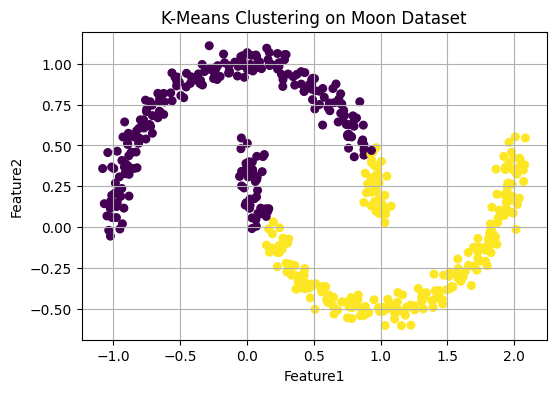

In [5]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["kmeans_cluster"],
    cmap="viridis",
    s=30
)

plt.title("K-Means Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.grid(True)

plt.show()

Q4. DBSCAN Clustering

In [6]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

# Fit and Predict
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

# Display first few rows
print(df.head())

   Feature1  Feature2  kmeans_cluster  dbscan_cluster
0  0.830586 -0.447733               1               0
1  0.701678  0.816918               0               1
2  1.022080 -0.492571               1               0
3 -0.316765  0.953438               0               1
4  0.293226  1.057185               0               1


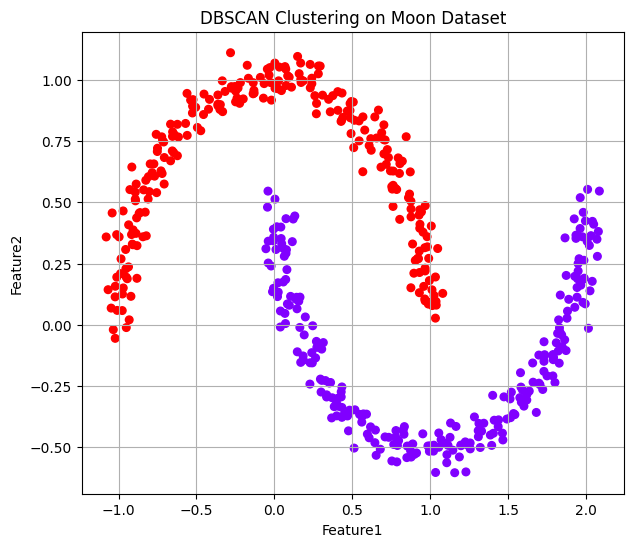

In [7]:
plt.figure(figsize=(7,6))

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["dbscan_cluster"],
    cmap="rainbow",
    s=30
)

plt.title("DBSCAN Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.grid(True)

plt.show()

Q5. Comparing K-Means vs DBSCAN

| K-Means                                                              | DBSCAN                                                                                         |
| -------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------- |
| Assumes spherical clusters.                                          | Detects clusters of any shape.                                                                 |
| Requires specifying the number of clusters beforehand.               | Does not require specifying the number of clusters.                                            |
| Cannot identify noise points.                                        | Detects noise points and labels them as **-1**.                                                |
| Performs poorly on the moon dataset because of its non-linear shape. | Performs much better on the moon dataset and separates the two moon-shaped clusters correctly. |


Q6. Tuning DBSCAN Parameters

In [8]:
eps_values = [0.2, 0.3, 0.4, 0.5]

results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)

    labels = db.fit_predict(X_scaled)

    # Count clusters (excluding noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count noise points
    noise_points = list(labels).count(-1)

    results.append([eps, n_clusters, noise_points])

# Create Results DataFrame
results_df = pd.DataFrame(
    results,
    columns=["eps", "Number of Clusters", "Noise Points"]
)

print(results_df)

   eps  Number of Clusters  Noise Points
0  0.2                   2             0
1  0.3                   2             0
2  0.4                   2             0
3  0.5                   2             0


Q7. Creating High-Dimensional Dataset

In [10]:
# Generate high-dimensional dataset
X_blob, y_blob = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

# Scale the data
scaler = StandardScaler()
X_blob_scaled = scaler.fit_transform(X_blob)

print("Shape of Original Dataset:", X_blob.shape)

Shape of Original Dataset: (500, 6)


Q8. Applying PCA

In [11]:
# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_blob_scaled)

# Create DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add original labels
pca_df["Cluster"] = y_blob

# Display first 5 rows
print(pca_df.head())

# Display explained variance ratio
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

        PC1       PC2  Cluster
0  2.369765  1.259783        1
1 -0.943367 -0.829777        3
2  0.982191 -1.768556        0
3  2.265086  1.190377        1
4  2.142129  0.840804        1

Explained Variance Ratio:
[0.64327878 0.21039738]


Q9. Visualizing PCA Results

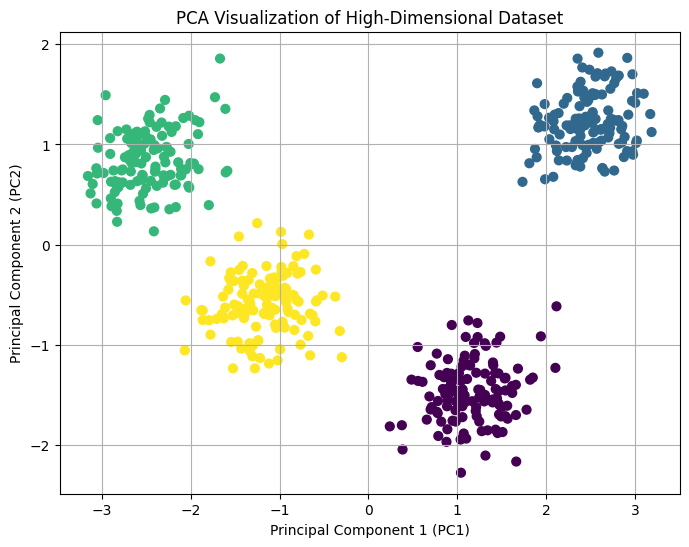

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=40
)

plt.title("PCA Visualization of High-Dimensional Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True)

plt.show()

Q10 (Mini Project – Complete Pipeline)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [3]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
X = df

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (150, 4)


In [7]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = clusters

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   DBSCAN_Cluster  
0               0  
1               0  
2               0  
3               0  
4               0  


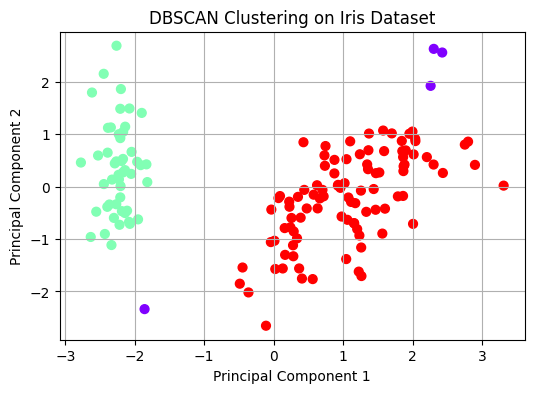

In [8]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,4))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="rainbow",
    s=40
)

plt.title("DBSCAN Clustering on Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

In [9]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(pca_df.head())

print("\nExplained Variance Ratio:")

print(pca.explained_variance_ratio_)

        PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835

Explained Variance Ratio:
[0.72962445 0.22850762]


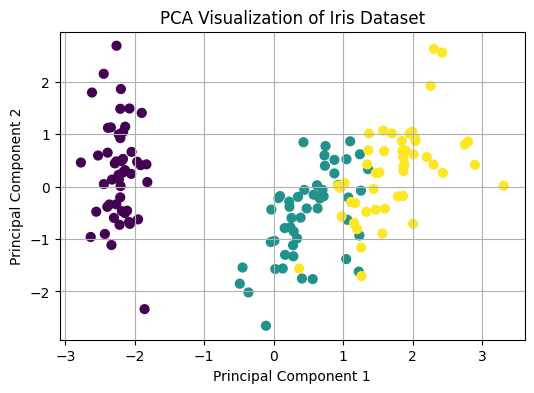

In [10]:
plt.figure(figsize=(6,4))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=iris.target,
    cmap="viridis",
    s=40
)

plt.title("PCA Visualization of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()